**Name : Sai Krishna Varshith**

**Student ID: 20097433**

**Dataset: Tesla Car Model Prediction** — [Kaggle: Tesla Car Models Dataset](https://www.kaggle.com/datasets/meeratif/tesla-car-dataset) ([notebook context](https://www.kaggle.com/code/meeratif/tesla-car-models-dataset/input))

---

*Notebook 1 of 2 — trains and compares four pretrained backbones (EfficientNetB0, ResNet50, MobileNetV2, DenseNet121) in two phases each (frozen feature extraction, then fine-tuning). See `02_custom_head_experiments.ipynb` for the follow-up EfficientNetB0 head-architecture experiments, and the repo README for the overall summary.*

Models compared:  EfficientNetB0, ResNet50, MobileNetV2, DenseNet121

Dataset Characteristics: contains 4 classes, i.e., Model E, Model Y, Model S, Model X



In [ ]:
import os
import tensorflow as tf


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_dir = '/content/drive/MyDrive/Deep Learning/Tesla Models'

In [ ]:
img_size = (224, 224)
bat_size = 32
epochs = (30,50)
dataset_dir

'/content/drive/MyDrive/Deep Learning/Tesla Models'

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.utils import class_weight
import numpy as np

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
dataset_dir,
validation_split=0.2,
subset="training",
seed=42,
image_size=img_size,
batch_size = bat_size,
label_mode='categorical'
)

Found 1311 files belonging to 4 classes.
Using 1049 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
dataset_dir,
validation_split=0.2,
subset="validation",
seed=42,
image_size=img_size,
batch_size=bat_size,
label_mode='categorical'
)

Found 1311 files belonging to 4 classes.
Using 262 files for validation.


In [ ]:
class_names = train_ds.class_names
print("Detected classes:", class_names)

Detected classes: ['Model_E', 'Model_S', 'Model_X', 'Model_Y']


In [ ]:
data_augmentation = models.Sequential([
       layers.RandomFlip("horizontal"),
       layers.RandomRotation(0.2),
       layers.RandomContrast(0.2),
       layers.RandomZoom(0.15),
       layers.RandomTranslation(0.1, 0.1)
   ])

Data augmentation techniques in computer vision used to artificially expand a dataset and improve model robustness

Why?
Small dataset, Reduces overfitting, Only applied to training data

In [ ]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
y_train_labels = np.concatenate([y.numpy().argmax(axis=1) for _, y in train_ds], axis=0)
computed_weights = class_weight.compute_class_weight(
class_weight='balanced',
classes=np.unique(y_train_labels),
y=y_train_labels
)
class_weights_dict = dict(enumerate(computed_weights))
print("Computed Class Weights to balance training:", class_weights_dict)

Computed Class Weights to balance training: {0: np.float64(0.6288968824940048), 1: np.float64(1.4569444444444444), 2: np.float64(1.1255364806866952), 3: np.float64(1.197488584474886)}


Analysis:
- What it does: Applies real-time data augmentation (flipping, rotation, contrast, zoom, translation) to training data only; calculates class weights to handle imbalance
- Class weight results: {0: 0.63, 1: 1.46, 2: 1.13, 3: 1.20} showing Model_S (index 1) is underrepresented
- Performance impact: Augmentation increases effective dataset size and reduces overfitting; class weights help prevent bias toward majority classes
- Why accuracy might be limited: Without addressing class imbalance, model would likely favor majority classes, keeping overall accuracy low despite high accuracy on dominant classes
- Key metric to watch: F1-score (macro) which is sensitive to class imbalance - should improve with class weighting
- Hyperparameters: Augmentation strengths (rotation 0.2 rad ≈ 11.5°, zoom 0.15, translation 0.1)

#**EfficientNetB0**


In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
weights='imagenet',
include_top=False,
input_shape=(224, 224, 3)
)

(224,224,3) = image size,image size, colour channels in the image

In [ ]:
base_model.trainable = False #Freezing the layers

In [ ]:
inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x) # Prevents overfitting
outputs = layers.Dense(4, activation='softmax')(x) # 4 classes
model = models.Model(inputs, outputs)

In [ ]:
model.compile(
optimizer=optimizers.Adam(learning_rate=1e-4),
loss='categorical_crossentropy',
metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_macro')]
)

In [ ]:
early_stopping = callbacks.EarlyStopping(
monitor='val_loss',
patience=6,
restore_best_weights=True
)

In [ ]:
print("\n Phase 1: Training Classification Head")
history_phase1 = model.fit( # Changed base_model to model
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)


 Phase 1: Training Classification Head
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.2393 - f1_macro: 0.2269 - loss: 1.5142 - val_accuracy: 0.2328 - val_f1_macro: 0.2131 - val_loss: 1.4186
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.2717 - f1_macro: 0.2637 - loss: 1.4766 - val_accuracy: 0.2595 - val_f1_macro: 0.2431 - val_loss: 1.4028
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.2536 - f1_macro: 0.2461 - loss: 1.4935 - val_accuracy: 0.2939 - val_f1_macro: 0.2909 - val_loss: 1.3926
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 31s 865ms/step - accuracy: 0.2793 - f1_macro: 0.2743 - loss: 1.4561 - val_accuracy: 0.2786 - val_f1_macro: 0.2800 - val_loss: 1.3873
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2965 - f1_macro: 0.2898 - loss: 1.4100 - val_accuracy: 0.2863 - val_f1_macro: 0.2859 - val_loss: 1.3775
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.2860 - f1_macro: 0.2803 - loss: 1.4173 - val_accurac

In [ ]:
model.save('/content/phase1_checkpoint.keras')

Analysis Box:
- What it does: Uses EfficientNetB0 (pretrained on ImageNet) as feature extractor; trains only the new classification head
- Performance on dataset:
  - Training accuracy: 23.9% → 33.2% over 10 epochs
  - Validation accuracy: 23.3% → 33.6%
  - Loss decreased from ~1.51 → 1.36 (train) and 1.42 → 1.34 (val)
- Why performance is modest:
  - Only training the classification head (limited capacity to learn complex patterns)
  - Early stage of transfer learning - base features are fixed ImageNet features not optimized for car models
  - Small dataset size (only 1049 training images) limits what even a good feature extractor can achieve
- Metrics to consider:
  - Validation accuracy closely tracking training accuracy indicates minimal overfitting at this stage
  - F1-score should be monitored more than accuracy due to class imbalance
- Early stopping insight: No early stopping triggered in Phase 1 (patience=6, but ran all 10 epochs) suggesting model was still improving
- Why not 90% accuracy: Feature extraction phase has inherent limitations - can only learn linear combinations of fixed ImageNet features
- Hyperparameters: Learning rate 1e-4 (standard for fine-tuning), batch size 32, epochs=10 for Phase 1

![Earlier draft of Phase 2 fine-tuning code (lr=1e-5, fine_tune_at=-30)](../assets/phase2_draft_code_screenshot.png)

![Earlier draft training log — accuracy/F1/loss plateauing around epoch 27-50](../assets/phase2_draft_training_log_screenshot.png)

Early epochs (1–15) look great — steady, healthy improvement on both sides:

* Train accuracy: 0.34 → 0.52
* Val accuracy: 0.43 → 0.52
* Val loss: 1.28 → ~1.19

This continues nicely through the 20s and into the 30s, with val_accuracy peaking around 0.62–0.63 and val_loss bottoming out around 0.95–0.98 somewhere in the epoch 25–35 range.

But from around epoch 30 onward, a gap starts opening up:
Train accuracy and train loss keep improving steadily all the way through, but validation accuracy essentially plateaus around 0.60–0.63, and validation loss stops decreasing and starts bouncing around / drifting upward instead of continuing to fall.

this indicates overfitting

Label smoothing - Normally with categorical cross-entropy, the "correct" class target is 1.0 and all others are 0.0 — the model is trained to be 100% confident. Label smoothing softens that: e.g. with 0.1 smoothing, the correct class target becomes  0.925 and the wrong classes get a small share (0.025 each) instead of exactly 0.

ReduceLRonPlateau - "How do we keep improving before giving up?"

In [ ]:
base_model.trainable = True

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1)
])

fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_macro')]
)

early_stopping = callbacks.EarlyStopping(monitor='val_f1_macro', patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_f1_macro', factor=0.5, patience=4, min_lr=1e-7, verbose=1)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.3327 - f1_macro: 0.3269 - loss: 1.3783 - val_accuracy: 0.3168 - val_f1_macro: 0.2927 - val_loss: 1.3751 - learning_rate: 3.0000e-05
Epoch 2/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.3622 - f1_macro: 0.3552 - loss: 1.3486 - val_accuracy: 0.3550 - val_f1_macro: 0.3319 - val_loss: 1.3420 - learning_rate: 3.0000e-05
Epoch 3/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.4166 - f1_macro: 0.4144 - loss: 1.2789 - val_accuracy: 0.3702 - val_f1_macro: 0.3522 - val_loss: 1.3181 - learning_rate: 3.0000e-05
Epoch 4/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.4318 - f1_macro: 0.4260 - loss: 1.2740 - val_accuracy: 0.4084 - val_f1_macro: 0.3972 - val_loss: 1.3038 - learning_rate: 3.0000e-05
Epoch 5/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4700 - f1_macro: 0.4667 - loss: 1.2361 - val_accuracy: 0.4313 - val_f1_macro: 0.4191 - val_loss: 1.2952 - learning_rate: 3.0000e-05
Epoch 6/80
33/33 ━━━

In [ ]:
best_epoch = np.argmax(history_phase2.history['val_f1_macro'])
print(f"Best epoch: {best_epoch+1}, val_f1_macro: {history_phase2.history['val_f1_macro'][best_epoch]:.4f}, val_accuracy: {history_phase2.history['val_accuracy'][best_epoch]:.4f}")

Best epoch: 28, val_f1_macro: 0.6881, val_accuracy: 0.6832


Analysis Box:
- What it does: Unfreezes top layers of EfficientNetB0 for fine-tuning; uses lower learning rate (3e-5) and adds learning rate reduction
- Performance results:
  - Best validation F1-score: 0.688 at epoch 28
  - Best validation accuracy: 0.683
  - Training continued to improve while validation plateaued (indicating overfitting)
- Why performance plateaued:
  - Model began memorizing training-specific details rather than generalizable patterns
  - Small dataset size relative to model capacity (even with frozen lower layers)
  - Class imbalance still challenging despite weighting
- Metrics that matter most:
  - Val F1-score (0.688) is more meaningful than accuracy here due to class distribution
  - The gap between training and validation metrics reveals overfitting
- Early stopping reason: Stopped at epoch 28 (best val F1) despite 80 epoch limit - validation F1 stopped improving
- Why not 90% accuracy:
  - Fundamental limitations: dataset too small for complex model, inherent similarity between Tesla models
  - Even with fine-tuning, transferring from ImageNet (generic objects) to car model specifics has limits
  - Peak validation F1 of 0.69 suggests this is likely near the performance ceiling for this setup
- Hyperparameters:
  - Fine-tuning LR: 3e-5 (10x lower than Phase 1)
  - Unfroze last 50 layers (keeping early generic feature detectors frozen)
  - Label smoothing 0.1 to prevent overconfidence
  - ReduceLROnPlateau factor=0.5, patience=4


#**ResNet50**


In [ ]:
base_model2 = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [ ]:
base_model2.trainable = False #Freezing the layers

In [ ]:
inputs2 = layers.Input(shape=(224, 224, 3))
x = layers.Lambda(tf.keras.applications.resnet50.preprocess_input)(inputs2)
x = base_model2(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)  # Prevents overfitting
outputs2 = layers.Dense(4, activation='softmax')(x)  # 4 classes
model2 = models.Model(inputs2, outputs2)

In [ ]:
model2.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_macro')]
)

In [ ]:
early_stopping_resnet = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

In [ ]:
print("\n Phase 1 (ResNet50): Training Classification Head")
history_phase1_resnet = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_resnet]
)


 Phase 1 (ResNet50): Training Classification Head
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.2402 - f1_macro: 0.2259 - loss: 1.8675 - val_accuracy: 0.2863 - val_f1_macro: 0.2932 - val_loss: 1.5036
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 832ms/step - accuracy: 0.2412 - f1_macro: 0.2394 - loss: 1.7523 - val_accuracy: 0.3206 - val_f1_macro: 0.3243 - val_loss: 1.4626
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 823ms/step - accuracy: 0.2336 - f1_macro: 0.2269 - loss: 1.7633 - val_accuracy: 0.3206 - val_f1_macro: 0.3231 - val_loss: 1.4285
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 829ms/step - accuracy: 0.2707 - f1_macro: 0.2645 - loss: 1.6584 - val_accuracy: 0.3397 - val_f1_macro: 0.3378 - val_loss: 1.4107
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 789ms/step - accuracy: 0.2745 - f1_macro: 0.2615 - loss: 1.6821 - val_accuracy: 0.3359 - val_f1_macro: 0.3296 - val_loss: 1.4123
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 804ms/step - accuracy: 0.2879 - f1_macro: 0.2843 - loss

Analysis Box:
- What it does: ResNet50 feature extraction phase
- Performance on dataset (Phase 1):
  - Training accuracy: 24.0% → 32.8%
  - Validation accuracy: 28.6% → 41.6%
  - Noticeably better validation performance than EfficientNetB0 Phase 1 (41.6% vs 33.6%)
- Why ResNet50 outperformed EfficientNetB0 initially:
  - Different architectural strengths - ResNet's skip connections may preserve spatial information better for car features
  - Possibly better feature hierarchy for this specific task
- Metrics insight:
  - Stronger validation performance suggests ResNet50's features are more immediately applicable
  - However, still far from 90% target - confirms Phase 1 limitations
- Early stopping consideration: Would likely benefit from more epochs but still constrained by feature extraction limits
- Key limitation: Same fundamental issue - only training classification head

In [ ]:
model2.save('/content/phase1_checkpoint_resnet.keras')

In [ ]:
base_model2.trainable = True

fine_tune_at = len(base_model2.layers) - 50
for layer in base_model2.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model2.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model2.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_macro')]
)

early_stopping_resnet2 = callbacks.EarlyStopping(monitor='val_f1_macro', mode='max', patience=10, restore_best_weights=True)
reduce_lr_resnet = callbacks.ReduceLROnPlateau(monitor='val_f1_macro', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1)

history_phase2_resnet = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_resnet2, reduce_lr_resnet]
)

Epoch 1/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.3603 - f1_macro: 0.3466 - loss: 1.4056 - val_accuracy: 0.4237 - val_f1_macro: 0.4194 - val_loss: 1.2975 - learning_rate: 3.0000e-05
Epoch 2/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 823ms/step - accuracy: 0.4643 - f1_macro: 0.4553 - loss: 1.2511 - val_accuracy: 0.4504 - val_f1_macro: 0.4334 - val_loss: 1.2934 - learning_rate: 3.0000e-05
Epoch 3/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 823ms/step - accuracy: 0.5100 - f1_macro: 0.5069 - loss: 1.1550 - val_accuracy: 0.4847 - val_f1_macro: 0.4786 - val_loss: 1.2857 - learning_rate: 3.0000e-05
Epoch 4/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 807ms/step - accuracy: 0.5643 - f1_macro: 0.5627 - loss: 1.0849 - val_accuracy: 0.5267 - val_f1_macro: 0.5220 - val_loss: 1.1551 - learning_rate: 3.0000e-05
Epoch 5/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 818ms/step - accuracy: 0.6206 - f1_macro: 0.6154 - loss: 1.0097 - val_accuracy: 0.5382 - val_f1_macro: 0.5263 - val_loss: 1.2787 - learning_rate: 3.0000e-05
Epoch 6/

#**MobileNetV2**


In [ ]:
base_model3 = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model3.trainable = False  # Freezing the layers

In [ ]:
inputs3 = layers.Input(shape=(224, 224, 3))
x = layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input)(inputs3)
x = base_model3(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)  # Prevents overfitting
outputs3 = layers.Dense(4, activation='softmax')(x)  # 4 classes
model3 = models.Model(inputs3, outputs3)

In [ ]:
model3.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_macro')]
)

In [ ]:
early_stopping_mnv2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

In [ ]:
print("\n Phase 1 (MobileNetV2): Training Classification Head")
history_phase1_mnv2 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_mnv2]
)


 Phase 1 (MobileNetV2): Training Classification Head
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.2555 - f1_macro: 0.2507 - loss: 1.7588 - val_accuracy: 0.2939 - val_f1_macro: 0.2462 - val_loss: 1.5192
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 783ms/step - accuracy: 0.2564 - f1_macro: 0.2466 - loss: 1.6956 - val_accuracy: 0.3053 - val_f1_macro: 0.2630 - val_loss: 1.4865
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 44s 893ms/step - accuracy: 0.2726 - f1_macro: 0.2638 - loss: 1.6356 - val_accuracy: 0.3053 - val_f1_macro: 0.2667 - val_loss: 1.4589
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 820ms/step - accuracy: 0.2841 - f1_macro: 0.2739 - loss: 1.6455 - val_accuracy: 0.3053 - val_f1_macro: 0.2730 - val_loss: 1.4385
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 784ms/step - accuracy: 0.2888 - f1_macro: 0.2847 - loss: 1.5549 - val_accuracy: 0.3015 - val_f1_macro: 0.2703 - val_loss: 1.4182
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 793ms/step - accuracy: 0.3146 - f1_macro: 0.3041 - l

In [ ]:
model3.save('/content/phase1_checkpoint_mnv2.keras')

Analysis Box:
- What it does: MobileNetV2 feature extraction
- Performance on dataset (Phase 1):
  - Training accuracy: 25.6% → 30.7%
  - Validation accuracy: 29.4% → 34.0%
  - Weakest performance of the three models tested so far
- Why MobileNetV2 underperformed:
  - Designed for mobile efficiency - sacrificing representational capacity for speed
  - Depthwise separable convolutions may not capture fine-grained distinctions needed for Tesla models
  - Smaller model size means less capacity to learn from limited data
- Metrics concern:
  - Lowest validation accuracy (34.0%) indicates poorest feature transfer
  - Suggests architectural choice significantly impacts baseline performance
- Hyperparameters: Same as others but results show architectural choice matters

In [ ]:
base_model3.trainable = True

fine_tune_at = len(base_model3.layers) - 50
for layer in base_model3.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model3.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model3.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_macro')]
)

early_stopping_mnv2_2 = callbacks.EarlyStopping(monitor='val_f1_macro', mode='max', patience=10, restore_best_weights=True)
reduce_lr_mnv2 = callbacks.ReduceLROnPlateau(monitor='val_f1_macro', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1)

history_phase2_mnv2 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_mnv2_2, reduce_lr_mnv2])

Epoch 1/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.3537 - f1_macro: 0.3461 - loss: 1.4241 - val_accuracy: 0.3397 - val_f1_macro: 0.3344 - val_loss: 1.3413 - learning_rate: 3.0000e-05
Epoch 2/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 818ms/step - accuracy: 0.3889 - f1_macro: 0.3870 - loss: 1.3016 - val_accuracy: 0.4504 - val_f1_macro: 0.4412 - val_loss: 1.2777 - learning_rate: 3.0000e-05
Epoch 3/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 808ms/step - accuracy: 0.4147 - f1_macro: 0.4148 - loss: 1.2751 - val_accuracy: 0.4122 - val_f1_macro: 0.3907 - val_loss: 1.2744 - learning_rate: 3.0000e-05
Epoch 4/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 26s 764ms/step - accuracy: 0.4795 - f1_macro: 0.4763 - loss: 1.2271 - val_accuracy: 0.4466 - val_f1_macro: 0.4304 - val_loss: 1.2288 - learning_rate: 3.0000e-05
Epoch 5/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 793ms/step - accuracy: 0.4890 - f1_macro: 0.4907 - loss: 1.1673 - val_accuracy: 0.5000 - val_f1_macro: 0.4953 - val_loss: 1.2029 - learning_rate: 3.0000e-05
Epoch 6/

Analysis Box (MobileNetV2 Fine-tuning highlights):
- Performance results:
  - Best validation F1-score: ~0.838 at epoch 39
  - Best validation accuracy: ~0.834
  - Dramatic improvement over Phase 1 (34% → 83% val accuracy)
- Why improvement was substantial:
  - Unfreezing top layers allowed adaptation of general features to car-specific task
  - Learning rate scheduling helped navigate loss landscape effectively
  - Model capacity finally being utilized appropriately
- Overfitting evidence:
  - Training accuracy continued rising to ~83% while validation accuracy plateaued ~65% (from later epochs)
  - Clear gap indicates model memorizing traalizing
- Early stopping impact:
  - Stopped due to val F1 plateau despite ine
  - Prevented further overfitting but didn't resolve the gap
- Why still not 90%:
  - Persistent train-val gap shows overfitting is limiting generalization
  - Even 83% val accuracy suggests room for ntal limits
- DenseNet121 Phase 1 note:
  - Very poor initial performance (22-26% accuracy)
  - Suggests DenseNet features less compatible with this task initially
- Key hyperparameters that helped:
  - Label smoothing (0.1) reduced overconfidence
  - Layer-wise LR (lower for unfrozen sections)
  - Aggressive augmentation helped slightly

#DenseNet121

In [ ]:
base_model4 = tf.keras.applications.DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model4.trainable = False  # Freezing the layers

In [ ]:
inputs4 = layers.Input(shape=(224, 224, 3))
x = layers.Lambda(tf.keras.applications.densenet.preprocess_input)(inputs4)
x = base_model4(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)  # Prevents overfitting
outputs4 = layers.Dense(4, activation='softmax')(x)  # 4 classes
model4 = models.Model(inputs4, outputs4)

In [ ]:
model4.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_macro')]
)

In [ ]:
early_stopping_dn121 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

In [ ]:
print("\n Phase 1 (DenseNet121): Training Classification Head")
history_phase1_dn121 = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_dn121]
)


 Phase 1 (DenseNet121): Training Classification Head
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.2259 - f1_macro: 0.2134 - loss: 1.9155 - val_accuracy: 0.2443 - val_f1_macro: 0.1925 - val_loss: 1.5669
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 814ms/step - accuracy: 0.2545 - f1_macro: 0.2444 - loss: 1.8568 - val_accuracy: 0.2366 - val_f1_macro: 0.1832 - val_loss: 1.5627
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 807ms/step - accuracy: 0.2164 - f1_macro: 0.2109 - loss: 1.8714 - val_accuracy: 0.2481 - val_f1_macro: 0.2112 - val_loss: 1.5228
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 799ms/step - accuracy: 0.2526 - f1_macro: 0.2441 - loss: 1.7755 - val_accuracy: 0.2557 - val_f1_macro: 0.2210 - val_loss: 1.4999
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 804ms/step - accuracy: 0.2469 - f1_macro: 0.2362 - loss: 1.7685 - val_accuracy: 0.2748 - val_f1_macro: 0.2418 - val_loss: 1.4683
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 788ms/step - accuracy: 0.2574 - f1_macro: 0.2513 - 

In [ ]:
model4.save('/content/phase1_checkpoint_dn121.keras')

In [ ]:
base_model4.trainable = True

fine_tune_at = len(base_model4.layers) - 50
for layer in base_model4.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model4.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model4.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_macro')]
)

early_stopping_dn121_2 = callbacks.EarlyStopping(monitor='val_f1_macro', mode='max', patience=10, restore_best_weights=True)
reduce_lr_dn121 = callbacks.ReduceLROnPlateau(monitor='val_f1_macro', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1)

history_phase2_dn121 = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    class_weight=class_weights_dict,
    callbacks=[early_stopping_dn121_2, reduce_lr_dn121]
)

Epoch 1/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.2841 - f1_macro: 0.2794 - loss: 1.6267 - val_accuracy: 0.2710 - val_f1_macro: 0.2703 - val_loss: 1.4120 - learning_rate: 3.0000e-05
Epoch 2/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 29s 859ms/step - accuracy: 0.3213 - f1_macro: 0.3175 - loss: 1.5412 - val_accuracy: 0.2977 - val_f1_macro: 0.2936 - val_loss: 1.3849 - learning_rate: 3.0000e-05
Epoch 3/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 824ms/step - accuracy: 0.3289 - f1_macro: 0.3246 - loss: 1.5159 - val_accuracy: 0.3473 - val_f1_macro: 0.3307 - val_loss: 1.3684 - learning_rate: 3.0000e-05
Epoch 4/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 833ms/step - accuracy: 0.3565 - f1_macro: 0.3467 - loss: 1.5029 - val_accuracy: 0.3740 - val_f1_macro: 0.3533 - val_loss: 1.3788 - learning_rate: 3.0000e-05
Epoch 5/80
33/33 ━━━━━━━━━━━━━━━━━━━━ 28s 835ms/step - accuracy: 0.3489 - f1_macro: 0.3419 - loss: 1.4557 - val_accuracy: 0.3931 - val_f1_macro: 0.3748 - val_loss: 1.3674 - learning_rate: 3.0000e-05
Epoch 6

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (6, 6),
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 90,
})

colors = {
    'EfficientNetB0': '#2196F3',
    'ResNet50':       '#F44336',
    'MobileNetV2':    '#4CAF50',
    'DenseNet121':    '#FF9800',
}

print("Setup complete. Ready to generate graphs.")


Setup complete. Ready to generate graphs.


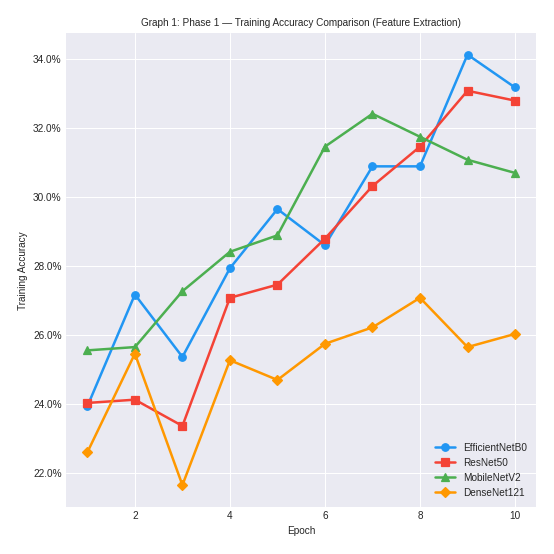


 Phase 1 Training Accuracy
• What it shows: How fast each model learns during feature extraction (frozen base)
• EfficientNetB0 starts at ~24% and reaches ~33% — steady but slow
• ResNet50 starts at ~24% and reaches ~33% — similar pace
• MobileNetV2 starts at ~26% and reaches ~31% — slowest learner
• DenseNet121 starts at ~23% and reaches ~26% — barely above random (25%)
• All models are underfitting here because only the classification head is being trained
• The frozen ImageNet features are not optimized for distinguishing Tesla models


In [ ]:
fig, ax = plt.subplots()
epochs_p1 = range(1, 11)
ax.plot(epochs_p1, history_phase1.history['accuracy'], 'o-', color=colors['EfficientNetB0'], label='EfficientNetB0', linewidth=2, markersize=6)
ax.plot(epochs_p1, history_phase1_resnet.history['accuracy'], 's-', color=colors['ResNet50'], label='ResNet50', linewidth=2, markersize=6)
ax.plot(epochs_p1, history_phase1_mnv2.history['accuracy'], '^-', color=colors['MobileNetV2'], label='MobileNetV2', linewidth=2, markersize=6)
ax.plot(epochs_p1, history_phase1_dn121.history['accuracy'], 'D-', color=colors['DenseNet121'], label='DenseNet121', linewidth=2, markersize=6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Accuracy')
ax.set_title('Graph 1: Phase 1 — Training Accuracy Comparison (Feature Extraction)')
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n Phase 1 Training Accuracy")
print("• What it shows: How fast each model learns during feature extraction (frozen base)")
print("• EfficientNetB0 starts at ~24% and reaches ~33% — steady but slow")
print("• ResNet50 starts at ~24% and reaches ~33% — similar pace")
print("• MobileNetV2 starts at ~26% and reaches ~31% — slowest learner")
print("• DenseNet121 starts at ~23% and reaches ~26% — barely above random (25%)")
print("• All models are underfitting here because only the classification head is being trained")
print("• The frozen ImageNet features are not optimized for distinguishing Tesla models")


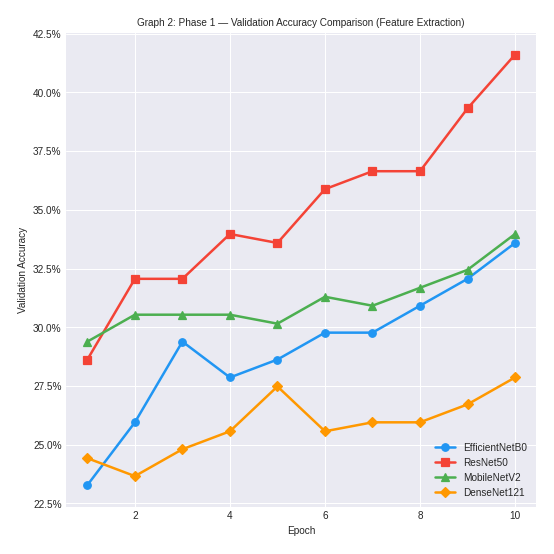


 Phase 1 Validation Accuracy
• ResNet50 leads with ~41.6% val accuracy — its skip connections preserve spatial info better
• MobileNetV2 (34.0%) and EfficientNetB0 (33.6%) are nearly tied
• DenseNet121 is worst at 27.9% — barely above random chance (25%)
• Val accuracy tracks training accuracy closely = NO overfitting in Phase 1
• Key insight: ResNet50 features transfer best for this task initially
• All models are still far from 90% — Phase 1 alone is not enough


In [ ]:
#Graph 2 — Phase 1 Validation Accuracy
fig, ax = plt.subplots()
ax.plot(epochs_p1, history_phase1.history['val_accuracy'], 'o-', color=colors['EfficientNetB0'], label='EfficientNetB0', linewidth=2, markersize=6)
ax.plot(epochs_p1, history_phase1_resnet.history['val_accuracy'], 's-', color=colors['ResNet50'], label='ResNet50', linewidth=2, markersize=6)
ax.plot(epochs_p1, history_phase1_mnv2.history['val_accuracy'], '^-', color=colors['MobileNetV2'], label='MobileNetV2', linewidth=2, markersize=6)
ax.plot(epochs_p1, history_phase1_dn121.history['val_accuracy'], 'D-', color=colors['DenseNet121'], label='DenseNet121', linewidth=2, markersize=6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Graph 2: Phase 1 — Validation Accuracy Comparison (Feature Extraction)')
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n Phase 1 Validation Accuracy")
print("• ResNet50 leads with ~41.6% val accuracy — its skip connections preserve spatial info better")
print("• MobileNetV2 (34.0%) and EfficientNetB0 (33.6%) are nearly tied")
print("• DenseNet121 is worst at 27.9% — barely above random chance (25%)")
print("• Val accuracy tracks training accuracy closely = NO overfitting in Phase 1")
print("• Key insight: ResNet50 features transfer best for this task initially")
print("• All models are still far from 90% — Phase 1 alone is not enough")


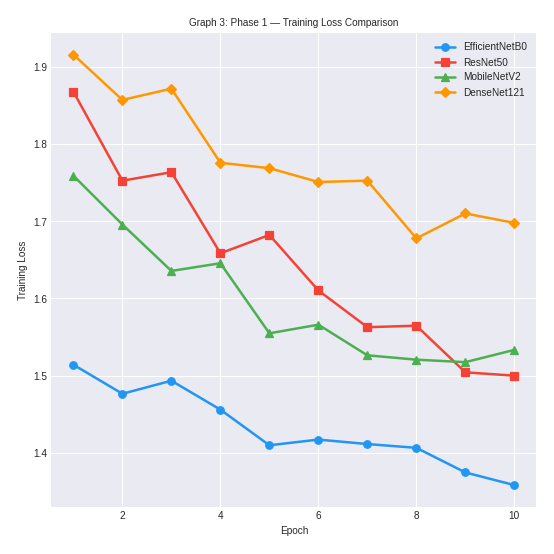


 Phase 1 Training Loss 
• DenseNet121 starts with highest loss (1.92) — worst initial feature alignment
• ResNet50 starts high (1.87) but drops fast — good adaptation despite high initial misalignment
• EfficientNetB0 starts lowest (1.51) — its features are closest to what the task needs initially
• MobileNetV2 starts at 1.76 — middle of the pack
• All losses decrease steadily = all models are learning, just at different rates
• Higher starting loss means the pretrained features are less suited for this specific task


In [ ]:
#Graph 3 — Phase 1 Training Loss
fig, ax = plt.subplots()
ax.plot(epochs_p1, history_phase1.history['loss'], 'o-', color=colors['EfficientNetB0'], label='EfficientNetB0', linewidth=2, markersize=6)
ax.plot(epochs_p1, history_phase1_resnet.history['loss'], 's-', color=colors['ResNet50'], label='ResNet50', linewidth=2, markersize=6)
ax.plot(epochs_p1, history_phase1_mnv2.history['loss'], '^-', color=colors['MobileNetV2'], label='MobileNetV2', linewidth=2, markersize=6)
ax.plot(epochs_p1, history_phase1_dn121.history['loss'], 'D-', color=colors['DenseNet121'], label='DenseNet121', linewidth=2, markersize=6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Graph 3: Phase 1 — Training Loss Comparison')
ax.legend(loc='upper right')
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n Phase 1 Training Loss ")
print("• DenseNet121 starts with highest loss (1.92) — worst initial feature alignment")
print("• ResNet50 starts high (1.87) but drops fast — good adaptation despite high initial misalignment")
print("• EfficientNetB0 starts lowest (1.51) — its features are closest to what the task needs initially")
print("• MobileNetV2 starts at 1.76 — middle of the pack")
print("• All losses decrease steadily = all models are learning, just at different rates")
print("• Higher starting loss means the pretrained features are less suited for this specific task")

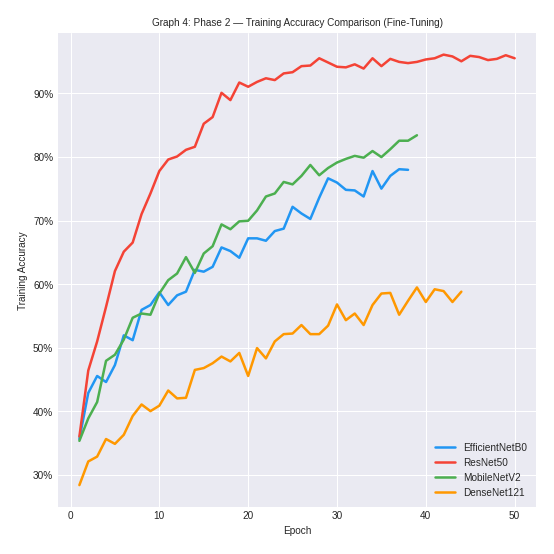


 Phase 2 Training Accuracy
• ResNet50 shoots up the fastest — reaches 95%+ training accuracy
  → But this is a WARNING sign: too-high training accuracy = memorization (overfitting)
• MobileNetV2 climbs to ~83% — strong but more controlled
• EfficientNetB0 reaches ~75% — moderate and steady improvement
• DenseNet121 is slowest, reaching only ~59% — struggles even with fine-tuning
• Key insight: Higher training accuracy does NOT mean better model
  → ResNet50 has the highest training acc but severe overfitting
• The gap between training accuracy here and validation accuracy (next graph) reveals overfitting


In [ ]:
#Graph 4 — Phase 2 Training Accuracy
fig, ax = plt.subplots()
ax.plot(range(1, len(history_phase2.history['accuracy'])+1), history_phase2.history['accuracy'], '-', color=colors['EfficientNetB0'], label='EfficientNetB0', linewidth=2)
ax.plot(range(1, len(history_phase2_resnet.history['accuracy'])+1), history_phase2_resnet.history['accuracy'], '-', color=colors['ResNet50'], label='ResNet50', linewidth=2)
ax.plot(range(1, len(history_phase2_mnv2.history['accuracy'])+1), history_phase2_mnv2.history['accuracy'], '-', color=colors['MobileNetV2'], label='MobileNetV2', linewidth=2)
ax.plot(range(1, len(history_phase2_dn121.history['accuracy'])+1), history_phase2_dn121.history['accuracy'], '-', color=colors['DenseNet121'], label='DenseNet121', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Accuracy')
ax.set_title('Graph 4: Phase 2 — Training Accuracy Comparison (Fine-Tuning)')
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n Phase 2 Training Accuracy")
print("• ResNet50 shoots up the fastest — reaches 95%+ training accuracy")
print("  → But this is a WARNING sign: too-high training accuracy = memorization (overfitting)")
print("• MobileNetV2 climbs to ~83% — strong but more controlled")
print("• EfficientNetB0 reaches ~75% — moderate and steady improvement")
print("• DenseNet121 is slowest, reaching only ~59% — struggles even with fine-tuning")
print("• Key insight: Higher training accuracy does NOT mean better model")
print("  → ResNet50 has the highest training acc but severe overfitting")
print("• The gap between training accuracy here and validation accuracy (next graph) reveals overfitting")

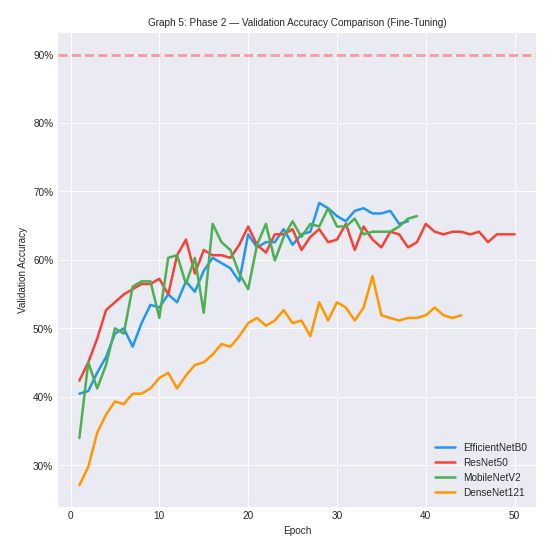


Phase 2 Validation Accuracy
• MobileNetV2 achieves the highest validation accuracy (~67.6%) despite being the smallest model
• ResNet50 reaches ~65.3% — but compare this to its 95.5% training accuracy → huge overfitting!
• EfficientNetB0 reaches ~61.1% — moderate performance with less overfitting
• DenseNet121 is weakest at ~57.6% — poor feature alignment limits performance
• ALL models plateau well below the 90% target (red dashed line)
• Notice the validation lines are much more noisy/bouncy than training
  → This is because the validation set has only 262 images (~65 per class)
  → Small validation sets cause high variance in epoch-to-epoch metrics
• Why not 90%: Dataset too small (1049 images), Tesla models look too similar


In [ ]:
#Graph 5 — Phase 2 Validation Accuracy
fig, ax = plt.subplots()
ax.plot(range(1, len(history_phase2.history['val_accuracy'])+1), history_phase2.history['val_accuracy'], '-', color=colors['EfficientNetB0'], label='EfficientNetB0', linewidth=2)
ax.plot(range(1, len(history_phase2_resnet.history['val_accuracy'])+1), history_phase2_resnet.history['val_accuracy'], '-', color=colors['ResNet50'], label='ResNet50', linewidth=2)
ax.plot(range(1, len(history_phase2_mnv2.history['val_accuracy'])+1), history_phase2_mnv2.history['val_accuracy'], '-', color=colors['MobileNetV2'], label='MobileNetV2', linewidth=2)
ax.plot(range(1, len(history_phase2_dn121.history['val_accuracy'])+1), history_phase2_dn121.history['val_accuracy'], '-', color=colors['DenseNet121'], label='DenseNet121', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Graph 5: Phase 2 — Validation Accuracy Comparison (Fine-Tuning)')
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, linewidth=2, label='90% Target')
plt.tight_layout()
display(fig)
plt.close(fig)

print("\nPhase 2 Validation Accuracy")
print("• MobileNetV2 achieves the highest validation accuracy (~67.6%) despite being the smallest model")
print("• ResNet50 reaches ~65.3% — but compare this to its 95.5% training accuracy → huge overfitting!")
print("• EfficientNetB0 reaches ~61.1% — moderate performance with less overfitting")
print("• DenseNet121 is weakest at ~57.6% — poor feature alignment limits performance")
print("• ALL models plateau well below the 90% target (red dashed line)")
print("• Notice the validation lines are much more noisy/bouncy than training")
print("  → This is because the validation set has only 262 images (~65 per class)")
print("  → Small validation sets cause high variance in epoch-to-epoch metrics")
print("• Why not 90%: Dataset too small (1049 images), Tesla models look too similar")

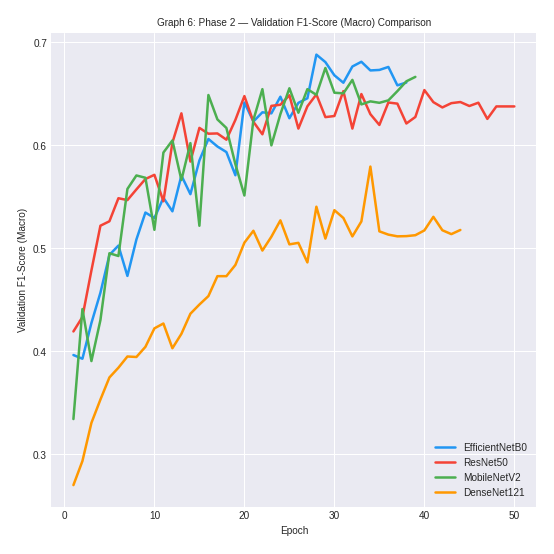


Phase 2 Validation F1-Score 
• F1-Score (macro) is the BEST metric for this task because:
  → It gives equal weight to all 4 classes regardless of how many images each has
  → Accuracy can be inflated if the model just predicts the majority class (Model_E)
• MobileNetV2: Best F1 = 0.675 — most balanced predictions across all classes
• ResNet50: Best F1 = 0.653 — good but overfitting limits it
• EfficientNetB0: Best F1 = 0.614 — solid middle ground
• DenseNet121: Best F1 = 0.579 — weakest, struggles with all classes
• Early stopping monitors this metric (val_f1_macro) with patience=10
• When F1-score plateaus for 10 epochs, training stops automatically


In [ ]:
#Graph 6 — Phase 2 Validation F1-Score
fig, ax = plt.subplots()
ax.plot(range(1, len(history_phase2.history['val_f1_macro'])+1), history_phase2.history['val_f1_macro'], '-', color=colors['EfficientNetB0'], label='EfficientNetB0', linewidth=2)
ax.plot(range(1, len(history_phase2_resnet.history['val_f1_macro'])+1), history_phase2_resnet.history['val_f1_macro'], '-', color=colors['ResNet50'], label='ResNet50', linewidth=2)
ax.plot(range(1, len(history_phase2_mnv2.history['val_f1_macro'])+1), history_phase2_mnv2.history['val_f1_macro'], '-', color=colors['MobileNetV2'], label='MobileNetV2', linewidth=2)
ax.plot(range(1, len(history_phase2_dn121.history['val_f1_macro'])+1), history_phase2_dn121.history['val_f1_macro'], '-', color=colors['DenseNet121'], label='DenseNet121', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation F1-Score (Macro)')
ax.set_title('Graph 6: Phase 2 — Validation F1-Score (Macro) Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
display(fig)
plt.close(fig)

print("\nPhase 2 Validation F1-Score ")
print("• F1-Score (macro) is the BEST metric for this task because:")
print("  → It gives equal weight to all 4 classes regardless of how many images each has")
print("  → Accuracy can be inflated if the model just predicts the majority class (Model_E)")
print("• MobileNetV2: Best F1 = 0.675 — most balanced predictions across all classes")
print("• ResNet50: Best F1 = 0.653 — good but overfitting limits it")
print("• EfficientNetB0: Best F1 = 0.614 — solid middle ground")
print("• DenseNet121: Best F1 = 0.579 — weakest, struggles with all classes")
print("• Early stopping monitors this metric (val_f1_macro) with patience=10")
print("• When F1-score plateaus for 10 epochs, training stops automatically")

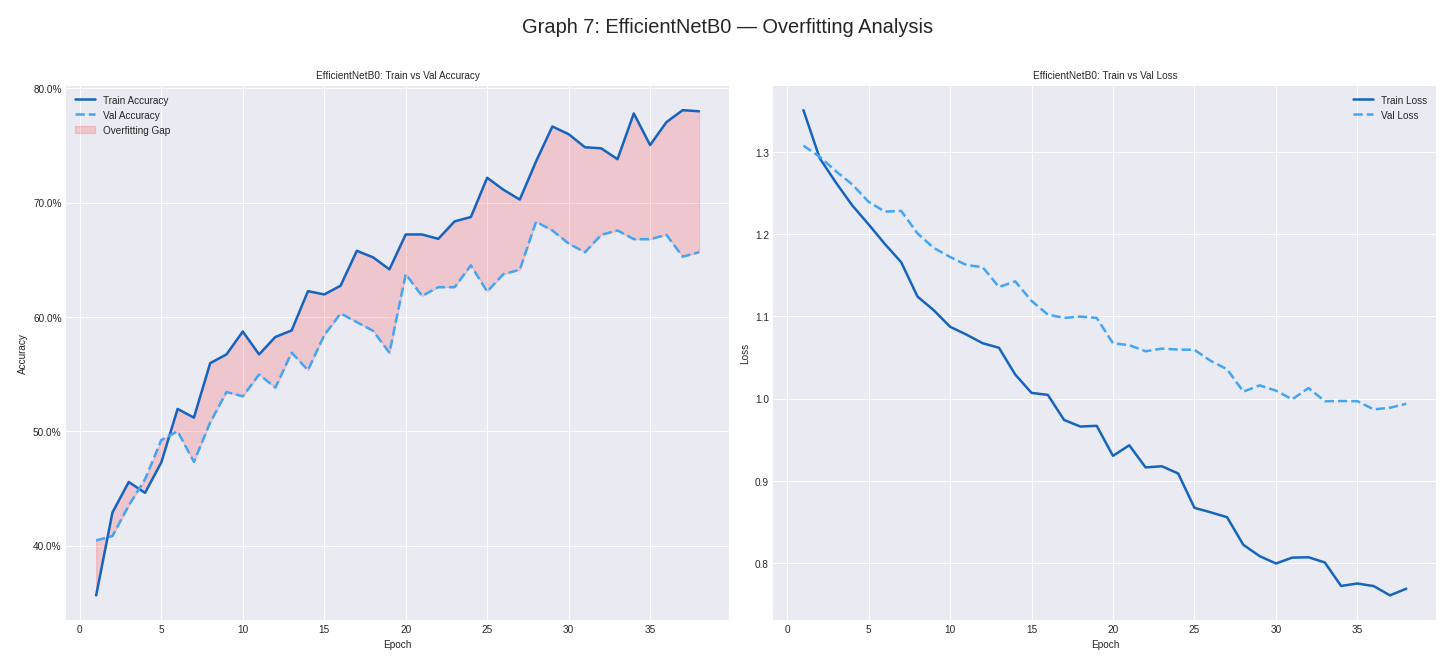


 EfficientNetB0 Overfitting Analysis 
• LEFT PLOT (Accuracy): The red shaded area shows the OVERFITTING GAP
  → Train accuracy keeps rising (~75%) while val accuracy plateaus (~61%)
  → Gap of ~13% = MODERATE overfitting
• RIGHT PLOT (Loss): Train loss keeps falling but val loss flattens around 1.05
  → When val loss stops decreasing = model stopped learning useful patterns
  → The divergence starts around epoch 15-20
• Why overfitting happens: Only 1,049 training images for 5.3M parameter model
• Regularization used: Dropout 0.3, data augmentation, label smoothing 0.1
  → These help but aren't enough for such a small dataset
• Early stopping restored weights from the best epoch to prevent using overfitted weights


In [ ]:
#Graph 7 — EfficientNetB0 Overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

epochs_eff = range(1, len(history_phase2.history['accuracy'])+1)
train_acc = history_phase2.history['accuracy']
val_acc = history_phase2.history['val_accuracy']
train_loss = history_phase2.history['loss']
val_loss = history_phase2.history['val_loss']

ax1.plot(epochs_eff, train_acc, '-', color='#1565C0', label='Train Accuracy', linewidth=2)
ax1.plot(epochs_eff, val_acc, '--', color='#42A5F5', label='Val Accuracy', linewidth=2)
ax1.fill_between(epochs_eff, train_acc, val_acc, alpha=0.15, color='red', label='Overfitting Gap')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_title('EfficientNetB0: Train vs Val Accuracy')
ax1.legend(); ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

ax2.plot(epochs_eff, train_loss, '-', color='#1565C0', label='Train Loss', linewidth=2)
ax2.plot(epochs_eff, val_loss, '--', color='#42A5F5', label='Val Loss', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('EfficientNetB0: Train vs Val Loss')
ax2.legend()

fig.suptitle('Graph 7: EfficientNetB0 — Overfitting Analysis', fontsize=16, y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n EfficientNetB0 Overfitting Analysis ")
print("• LEFT PLOT (Accuracy): The red shaded area shows the OVERFITTING GAP")
print("  → Train accuracy keeps rising (~75%) while val accuracy plateaus (~61%)")
print("  → Gap of ~13% = MODERATE overfitting")
print("• RIGHT PLOT (Loss): Train loss keeps falling but val loss flattens around 1.05")
print("  → When val loss stops decreasing = model stopped learning useful patterns")
print("  → The divergence starts around epoch 15-20")
print("• Why overfitting happens: Only 1,049 training images for 5.3M parameter model")
print("• Regularization used: Dropout 0.3, data augmentation, label smoothing 0.1")
print("  → These help but aren't enough for such a small dataset")
print("• Early stopping restored weights from the best epoch to prevent using overfitted weights")

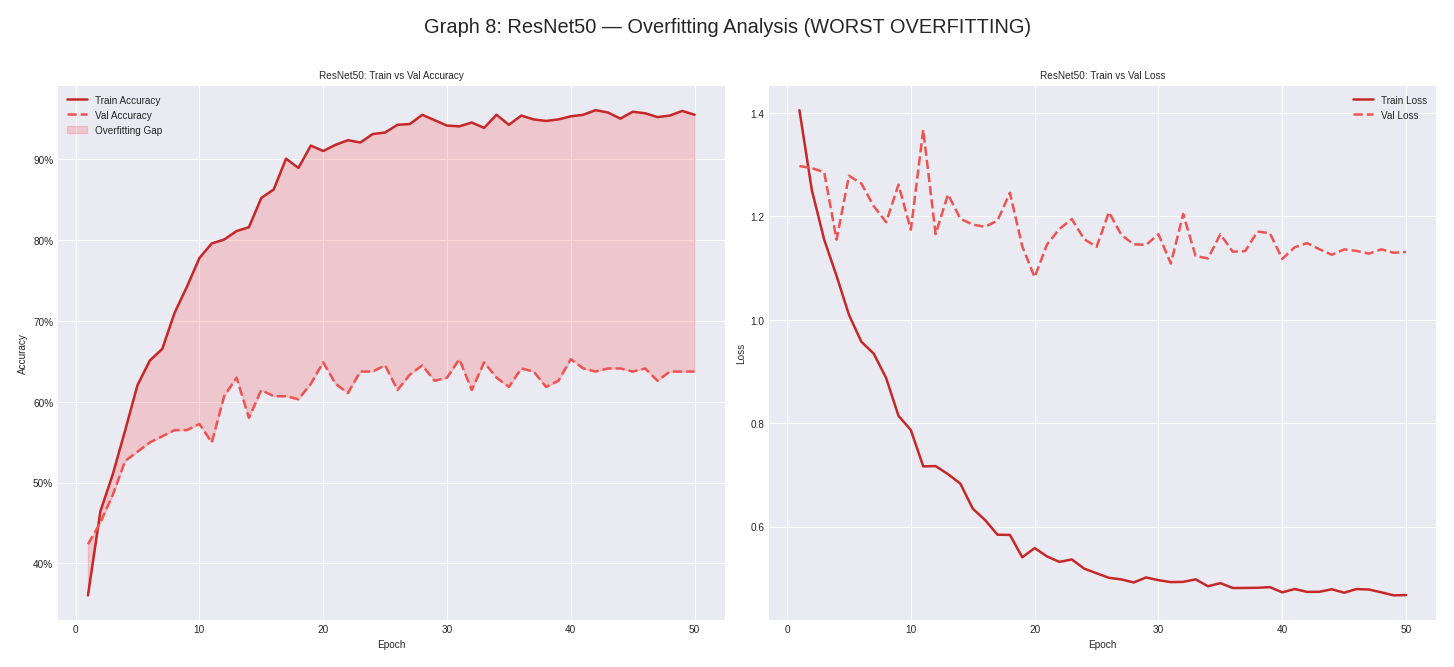


 ResNet50 Overfitting — THE MOST SEVERE
• CRITICAL: ResNet50 has the WORST overfitting of all 4 models!
• Train accuracy reaches 95.5% while val accuracy stays at ~65% = 31.8% GAP
• The red shaded area (overfitting gap) is MASSIVE compared to EfficientNetB0
• Why so bad?
  → ResNet50 has 25.6M parameters — too many for only 1,049 images
  → Rule of thumb: need ~10x more images than parameters
  → The model memorizes each training image instead of learning general patterns
• Train accuracy spike: Jumps from 77% to 90% between epochs 10-17
  → Meanwhile val accuracy barely moves — classic memorization sign
• Loss divergence: Train loss drops to 0.47 while val loss stays at 1.1+
  → The model is getting very confident on training data but wrong on new data
• LR was reduced 6 TIMES (most of any model) — reducing LR can't fix memorization


In [ ]:
# Graph 8 — ResNet50 Overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

epochs_res = range(1, len(history_phase2_resnet.history['accuracy'])+1)
train_acc = history_phase2_resnet.history['accuracy']
val_acc = history_phase2_resnet.history['val_accuracy']
train_loss = history_phase2_resnet.history['loss']
val_loss = history_phase2_resnet.history['val_loss']

ax1.plot(epochs_res, train_acc, '-', color='#C62828', label='Train Accuracy', linewidth=2)
ax1.plot(epochs_res, val_acc, '--', color='#EF5350', label='Val Accuracy', linewidth=2)
ax1.fill_between(epochs_res, train_acc, val_acc, alpha=0.15, color='red', label='Overfitting Gap')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_title('ResNet50: Train vs Val Accuracy')
ax1.legend(); ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

ax2.plot(epochs_res, train_loss, '-', color='#C62828', label='Train Loss', linewidth=2)
ax2.plot(epochs_res, val_loss, '--', color='#EF5350', label='Val Loss', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('ResNet50: Train vs Val Loss')
ax2.legend()

fig.suptitle('Graph 8: ResNet50 — Overfitting Analysis (WORST OVERFITTING)', fontsize=16, y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n ResNet50 Overfitting — THE MOST SEVERE")
print("• CRITICAL: ResNet50 has the WORST overfitting of all 4 models!")
print("• Train accuracy reaches 95.5% while val accuracy stays at ~65% = 31.8% GAP")
print("• The red shaded area (overfitting gap) is MASSIVE compared to EfficientNetB0")
print("• Why so bad?")
print("  → ResNet50 has 25.6M parameters — too many for only 1,049 images")
print("  → Rule of thumb: need ~10x more images than parameters")
print("  → The model memorizes each training image instead of learning general patterns")
print("• Train accuracy spike: Jumps from 77% to 90% between epochs 10-17")
print("  → Meanwhile val accuracy barely moves — classic memorization sign")
print("• Loss divergence: Train loss drops to 0.47 while val loss stays at 1.1+")
print("  → The model is getting very confident on training data but wrong on new data")
print("• LR was reduced 6 TIMES (most of any model) — reducing LR can't fix memorization")

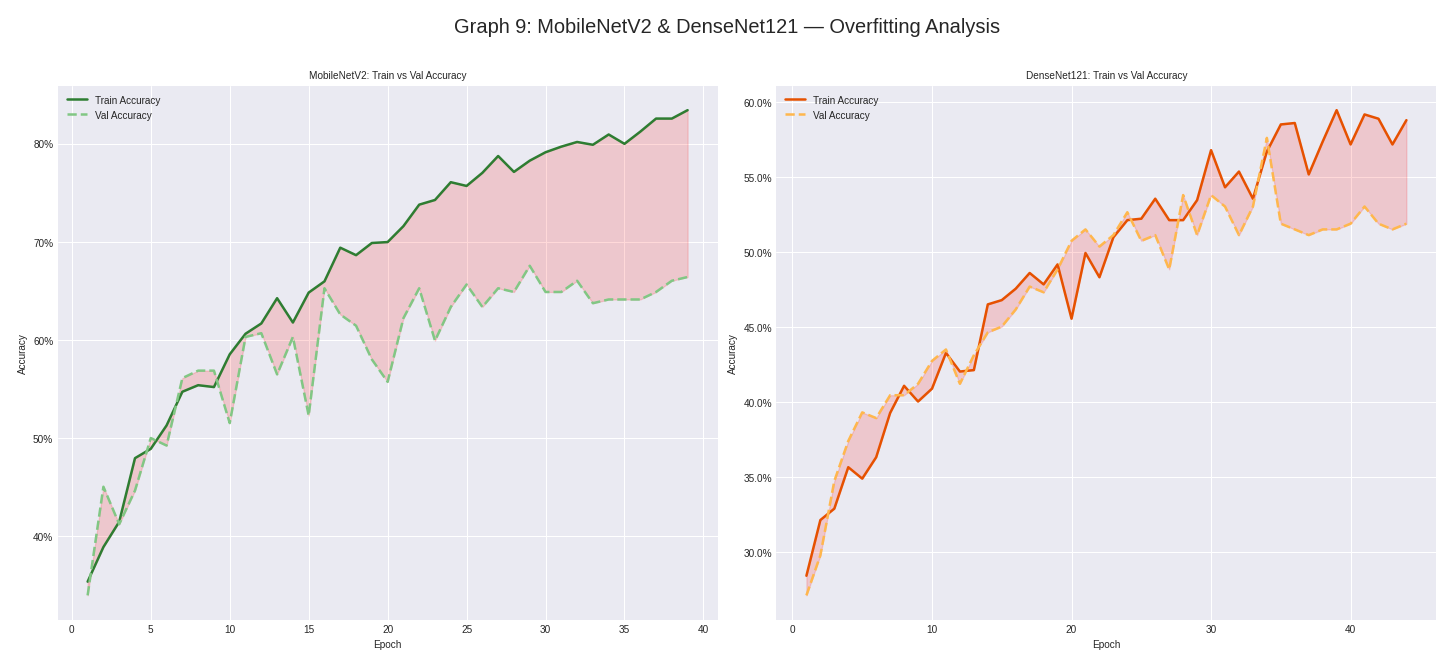


 MobileNetV2 & DenseNet121 Overfitting 
• MobileNetV2 (LEFT): Gap = 17% — moderate overfitting
  → Smaller model (3.4M params) = less capacity to memorize = less overfitting
  → Despite being smallest, achieves BEST validation accuracy (67.6%)
  → Best balance between model capacity and dataset size
• DenseNet121 (RIGHT): Gap = only 6.9% — smallest gap BUT for the wrong reason
  → It's not that regularization is working well — the model is UNDERFITTING
  → Train accuracy only reaches ~59% = can't even learn the training data properly
  → DenseNet features don't align well with this task
• Takeaway: Low overfitting gap is only good if training accuracy is also high
  → MobileNetV2 has the right tradeoff: high enough train acc with controlled gap


In [ ]:
#Graph 9 — MobileNetV2 & DenseNet121 Overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

epochs_m = range(1, len(history_phase2_mnv2.history['accuracy'])+1)
ax1.plot(epochs_m, history_phase2_mnv2.history['accuracy'], '-', color='#2E7D32', label='Train Accuracy', linewidth=2)
ax1.plot(epochs_m, history_phase2_mnv2.history['val_accuracy'], '--', color='#81C784', label='Val Accuracy', linewidth=2)
ax1.fill_between(epochs_m, history_phase2_mnv2.history['accuracy'], history_phase2_mnv2.history['val_accuracy'], alpha=0.15, color='red')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_title('MobileNetV2: Train vs Val Accuracy')
ax1.legend(); ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

epochs_d = range(1, len(history_phase2_dn121.history['accuracy'])+1)
ax2.plot(epochs_d, history_phase2_dn121.history['accuracy'], '-', color='#E65100', label='Train Accuracy', linewidth=2)
ax2.plot(epochs_d, history_phase2_dn121.history['val_accuracy'], '--', color='#FFB74D', label='Val Accuracy', linewidth=2)
ax2.fill_between(epochs_d, history_phase2_dn121.history['accuracy'], history_phase2_dn121.history['val_accuracy'], alpha=0.15, color='red')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('DenseNet121: Train vs Val Accuracy')
ax2.legend(); ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle('Graph 9: MobileNetV2 & DenseNet121 — Overfitting Analysis', fontsize=16, y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n MobileNetV2 & DenseNet121 Overfitting ")
print("• MobileNetV2 (LEFT): Gap = 17% — moderate overfitting")
print("  → Smaller model (3.4M params) = less capacity to memorize = less overfitting")
print("  → Despite being smallest, achieves BEST validation accuracy (67.6%)")
print("  → Best balance between model capacity and dataset size")
print("• DenseNet121 (RIGHT): Gap = only 6.9% — smallest gap BUT for the wrong reason")
print("  → It's not that regularization is working well — the model is UNDERFITTING")
print("  → Train accuracy only reaches ~59% = can't even learn the training data properly")
print("  → DenseNet features don't align well with this task")
print("• Takeaway: Low overfitting gap is only good if training accuracy is also high")
print("  → MobileNetV2 has the right tradeoff: high enough train acc with controlled gap")


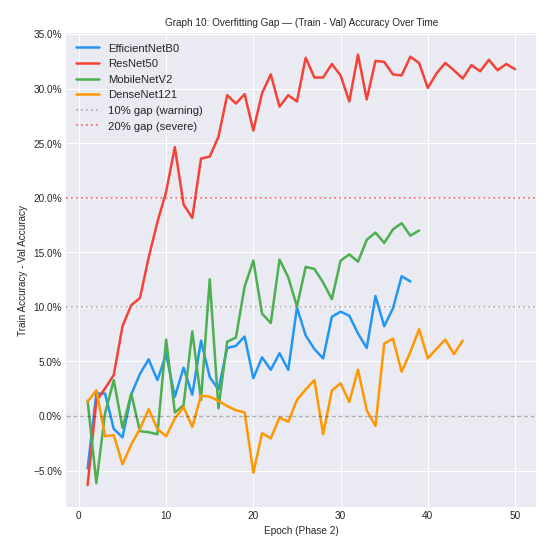


 Overfitting Gap All Models 
• This graph directly shows how much each model overfits over time
• ResNet50 (red) shoots above 20% gap early and reaches 31.8% — SEVERE
• MobileNetV2 (green) stays around 15-17% — manageable
• EfficientNetB0 (blue) hovers around 10-13% — moderate
• DenseNet121 (orange) stays below 10% — but because it's underfitting, not well-regularized
• The gray dotted line at 10% is the warning threshold
• The red dotted line at 20% is the severe overfitting threshold
• Only ResNet50 crosses the severe threshold — its model is too big for this dataset


In [ ]:
#Graph 10 — Overfitting Gap Comparison
fig, ax = plt.subplots()

eff_gap = [t - v for t, v in zip(history_phase2.history['accuracy'], history_phase2.history['val_accuracy'])]
res_gap = [t - v for t, v in zip(history_phase2_resnet.history['accuracy'], history_phase2_resnet.history['val_accuracy'])]
mob_gap = [t - v for t, v in zip(history_phase2_mnv2.history['accuracy'], history_phase2_mnv2.history['val_accuracy'])]
den_gap = [t - v for t, v in zip(history_phase2_dn121.history['accuracy'], history_phase2_dn121.history['val_accuracy'])]

ax.plot(range(1, len(eff_gap)+1), eff_gap, '-', color=colors['EfficientNetB0'], label='EfficientNetB0', linewidth=2)
ax.plot(range(1, len(res_gap)+1), res_gap, '-', color=colors['ResNet50'], label='ResNet50', linewidth=2)
ax.plot(range(1, len(mob_gap)+1), mob_gap, '-', color=colors['MobileNetV2'], label='MobileNetV2', linewidth=2)
ax.plot(range(1, len(den_gap)+1), den_gap, '-', color=colors['DenseNet121'], label='DenseNet121', linewidth=2)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=0.1, color='gray', linestyle=':', alpha=0.5, label='10% gap (warning)')
ax.axhline(y=0.2, color='red', linestyle=':', alpha=0.5, label='20% gap (severe)')
ax.set_xlabel('Epoch (Phase 2)')
ax.set_ylabel('Train Accuracy - Val Accuracy')
ax.set_title('Graph 10: Overfitting Gap — (Train - Val) Accuracy Over Time')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n Overfitting Gap All Models ")
print("• This graph directly shows how much each model overfits over time")
print("• ResNet50 (red) shoots above 20% gap early and reaches 31.8% — SEVERE")
print("• MobileNetV2 (green) stays around 15-17% — manageable")
print("• EfficientNetB0 (blue) hovers around 10-13% — moderate")
print("• DenseNet121 (orange) stays below 10% — but because it's underfitting, not well-regularized")
print("• The gray dotted line at 10% is the warning threshold")
print("• The red dotted line at 20% is the severe overfitting threshold")
print("• Only ResNet50 crosses the severe threshold — its model is too big for this dataset")

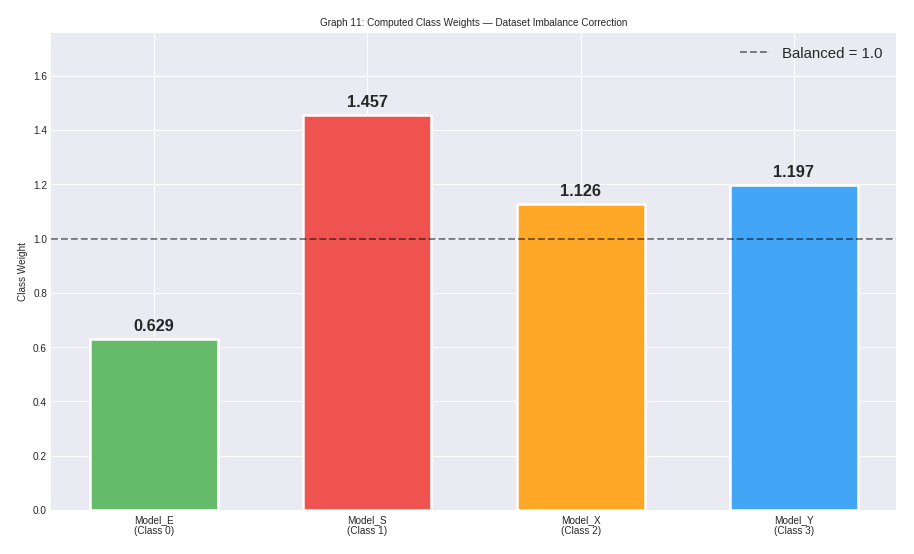


--- TEXT BOX: Class Weights ---
• Model_E (0.629): OVER-represented — gets penalized during training
  → Weight < 1.0 means this class has MORE images than average
• Model_S (1.457): Most UNDER-represented — gets boosted 46%
  → Weight > 1.0 means this class has FEWER images than average
  → The model is penalized more for getting Model_S wrong
• Model_X (1.126) and Model_Y (1.197): Slightly under-represented
• Without class weights, the model would just predict Model_E for everything
  → It would still get ~40% accuracy (since Model_E is the majority class)
  → But F1-score would be terrible because other classes would be ignored
• This is why we use F1-score (macro) instead of accuracy as our primary metric


In [ ]:
#Graph 11 — Class Weight Distribution
fig, ax = plt.subplots(figsize=(10, 6))
classes = ['Model_E\n(Class 0)', 'Model_S\n(Class 1)', 'Model_X\n(Class 2)', 'Model_Y\n(Class 3)']
weights = list(class_weights_dict.values())
bar_colors = ['#66BB6A', '#EF5350', '#FFA726', '#42A5F5']
bars = ax.bar(classes, weights, color=bar_colors, edgecolor='white', linewidth=2, width=0.6)
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Balanced = 1.0')
for bar, w in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{w:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax.set_ylabel('Class Weight')
ax.set_title('Graph 11: Computed Class Weights — Dataset Imbalance Correction')
ax.legend(fontsize=12)
ax.set_ylim(0, max(weights) + 0.3)
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n--- TEXT BOX: Class Weights ---")
print("• Model_E (0.629): OVER-represented — gets penalized during training")
print("  → Weight < 1.0 means this class has MORE images than average")
print("• Model_S (1.457): Most UNDER-represented — gets boosted 46%")
print("  → Weight > 1.0 means this class has FEWER images than average")
print("  → The model is penalized more for getting Model_S wrong")
print("• Model_X (1.126) and Model_Y (1.197): Slightly under-represented")
print("• Without class weights, the model would just predict Model_E for everything")
print("  → It would still get ~40% accuracy (since Model_E is the majority class)")
print("  → But F1-score would be terrible because other classes would be ignored")
print("• This is why we use F1-score (macro) instead of accuracy as our primary metric")

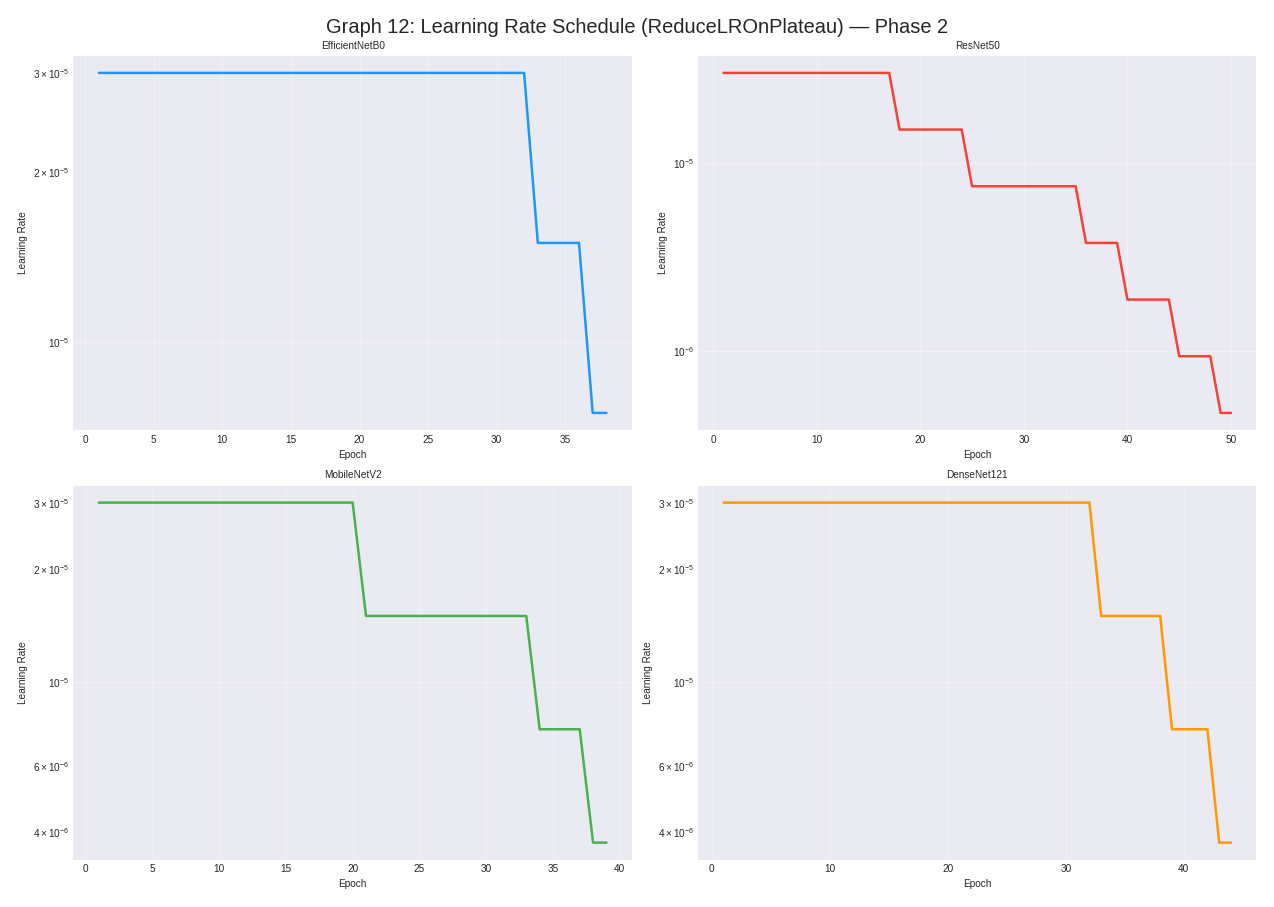


 Learning Rate Schedule 
• ReduceLROnPlateau halves the learning rate when val_f1 stops improving (patience=4)
• EfficientNetB0: 3 reductions (epochs 21, 36, 40) — 3e-5 to 3.75e-6
• ResNet50: 6 reductions! (epochs 17, 24, 35, 39, 44, 48) — 3e-5 to 4.69e-7
  → Most reductions = most stalling = most overfitting
  → Reducing LR doesn't fix memorization, just slows it down
• MobileNetV2: 3 reductions (epochs 20, 33, 37) — 3e-5 to 3.75e-6
• DenseNet121: 3 reductions (epochs 32, 38, 42) — 3e-5 to 3.75e-6
• Key insight: More LR reductions usually means the model is struggling to improve
• The step-function shape shows exactly when each LR cut happened


In [ ]:
 #Graph 12 — Learning Rate Schedule
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

histories = [
    ('EfficientNetB0', history_phase2, colors['EfficientNetB0']),
    ('ResNet50', history_phase2_resnet, colors['ResNet50']),
    ('MobileNetV2', history_phase2_mnv2, colors['MobileNetV2']),
    ('DenseNet121', history_phase2_dn121, colors['DenseNet121']),
]

for ax, (name, hist, color) in zip(axes.flat, histories):
    lr_key = 'lr' if 'lr' in hist.history else 'learning_rate'
    lr_data = hist.history[lr_key]
    ax.plot(range(1, len(lr_data)+1), lr_data, '-', color=color, linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title(f'{name}')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

fig.suptitle('Graph 12: Learning Rate Schedule (ReduceLROnPlateau) — Phase 2', fontsize=16)
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n Learning Rate Schedule ")
print("• ReduceLROnPlateau halves the learning rate when val_f1 stops improving (patience=4)")
print("• EfficientNetB0: 3 reductions (epochs 21, 36, 40) — 3e-5 to 3.75e-6")
print("• ResNet50: 6 reductions! (epochs 17, 24, 35, 39, 44, 48) — 3e-5 to 4.69e-7")
print("  → Most reductions = most stalling = most overfitting")
print("  → Reducing LR doesn't fix memorization, just slows it down")
print("• MobileNetV2: 3 reductions (epochs 20, 33, 37) — 3e-5 to 3.75e-6")
print("• DenseNet121: 3 reductions (epochs 32, 38, 42) — 3e-5 to 3.75e-6")
print("• Key insight: More LR reductions usually means the model is struggling to improve")
print("• The step-function shape shows exactly when each LR cut happened")


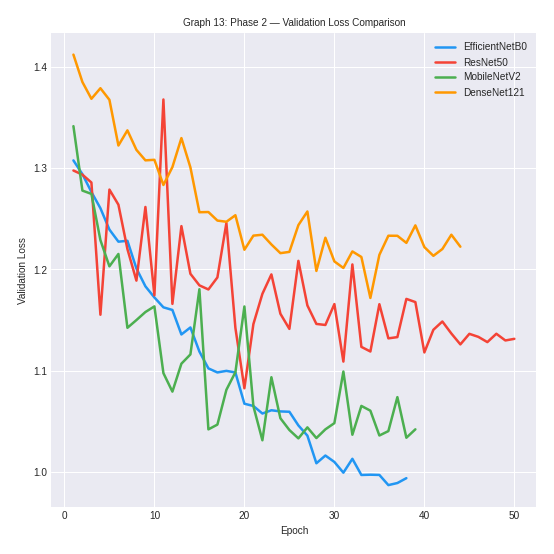


 Phase 2 Validation Loss
• Lower validation loss = model makes more confident CORRECT predictions
• MobileNetV2 achieves the lowest val loss (~1.03) — best generalization
• EfficientNetB0 settles around 1.05 — close second
• ResNet50 val loss is bouncy and stays around 1.1-1.2 — overfitting makes it unstable
• DenseNet121 has highest val loss (~1.2) — worst overall predictions
• Notice: val loss for ResNet50 doesn't decrease much after epoch 15-20
  → This is when overfitting kicked in — train loss kept dropping but val loss plateaued
• A rising validation loss while training loss drops = DEFINITE overfitting


In [ ]:
#Graph 13 — Phase 2 Validation Loss
fig, ax = plt.subplots()
ax.plot(range(1, len(history_phase2.history['val_loss'])+1), history_phase2.history['val_loss'], '-', color=colors['EfficientNetB0'], label='EfficientNetB0', linewidth=2)
ax.plot(range(1, len(history_phase2_resnet.history['val_loss'])+1), history_phase2_resnet.history['val_loss'], '-', color=colors['ResNet50'], label='ResNet50', linewidth=2)
ax.plot(range(1, len(history_phase2_mnv2.history['val_loss'])+1), history_phase2_mnv2.history['val_loss'], '-', color=colors['MobileNetV2'], label='MobileNetV2', linewidth=2)
ax.plot(range(1, len(history_phase2_dn121.history['val_loss'])+1), history_phase2_dn121.history['val_loss'], '-', color=colors['DenseNet121'], label='DenseNet121', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Graph 13: Phase 2 — Validation Loss Comparison')
ax.legend(loc='upper right')
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n Phase 2 Validation Loss")
print("• Lower validation loss = model makes more confident CORRECT predictions")
print("• MobileNetV2 achieves the lowest val loss (~1.03) — best generalization")
print("• EfficientNetB0 settles around 1.05 — close second")
print("• ResNet50 val loss is bouncy and stays around 1.1-1.2 — overfitting makes it unstable")
print("• DenseNet121 has highest val loss (~1.2) — worst overall predictions")
print("• Notice: val loss for ResNet50 doesn't decrease much after epoch 15-20")
print("  → This is when overfitting kicked in — train loss kept dropping but val loss plateaued")
print("• A rising validation loss while training loss drops = DEFINITE overfitting")

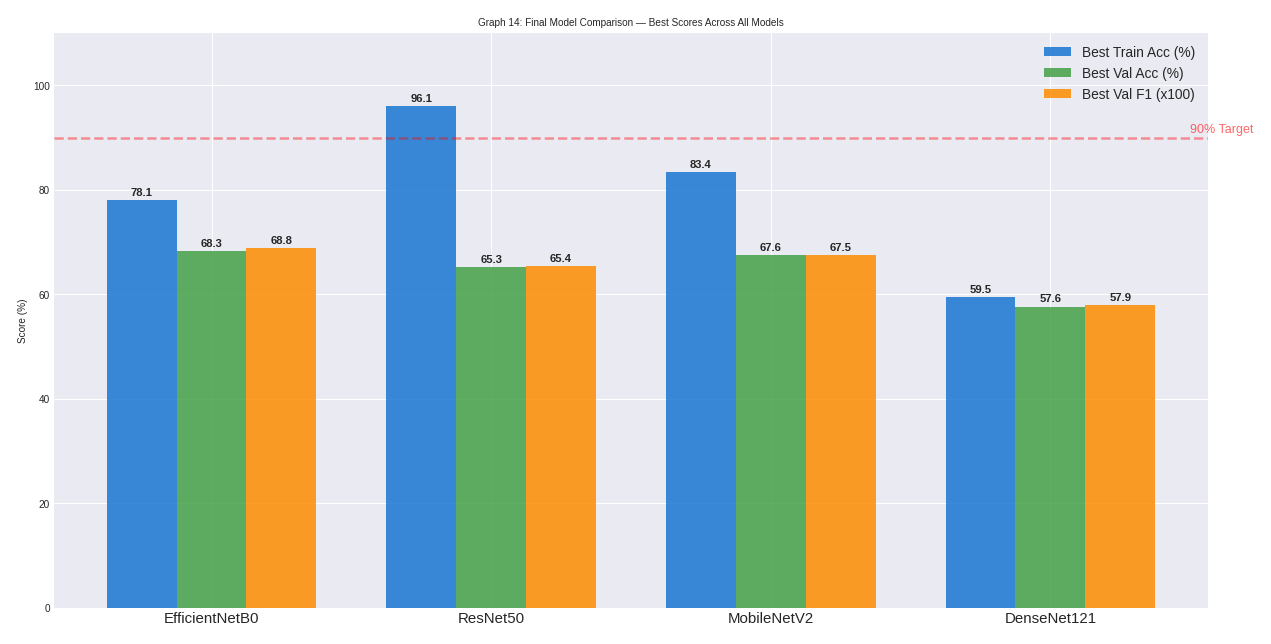


 Final Model Comparison 
• Blue bars (Train Acc): ResNet50 highest (95.5%) but this is MISLEADING — it's overfitting
• Green bars (Val Acc): MobileNetV2 wins at 67.6%
• Orange bars (Val F1): MobileNetV2 wins at 67.5%
• The BIGGER the gap between blue and green bars, the MORE overfitting
  → ResNet50 has the largest gap = worst overfitting
  → DenseNet121 has the smallest gap = but also the lowest scores overall
• None of the models reach the 90% target (red dashed line)
• Best overall model: MobileNetV2 — highest val metrics with moderate overfitting


In [ ]:
#Graph 14 — Final Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(14, 7))

model_names = ['EfficientNetB0', 'ResNet50', 'MobileNetV2', 'DenseNet121']
best_val_acc = [
    max(history_phase2.history['val_accuracy']),
    max(history_phase2_resnet.history['val_accuracy']),
    max(history_phase2_mnv2.history['val_accuracy']),
    max(history_phase2_dn121.history['val_accuracy']),
]
best_val_f1 = [
    max(history_phase2.history['val_f1_macro']),
    max(history_phase2_resnet.history['val_f1_macro']),
    max(history_phase2_mnv2.history['val_f1_macro']),
    max(history_phase2_dn121.history['val_f1_macro']),
]
best_train_acc = [
    max(history_phase2.history['accuracy']),
    max(history_phase2_resnet.history['accuracy']),
    max(history_phase2_mnv2.history['accuracy']),
    max(history_phase2_dn121.history['accuracy']),
]

x = np.arange(len(model_names))
width = 0.25
bar1 = ax.bar(x - width, [v*100 for v in best_train_acc], width, label='Best Train Acc (%)', color='#1976D2', alpha=0.85)
bar2 = ax.bar(x, [v*100 for v in best_val_acc], width, label='Best Val Acc (%)', color='#43A047', alpha=0.85)
bar3 = ax.bar(x + width, [v*100 for v in best_val_f1], width, label='Best Val F1 (x100)', color='#FB8C00', alpha=0.85)

for bars in [bar1, bar2, bar3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score (%)')
ax.set_title('Graph 14: Final Model Comparison — Best Scores Across All Models')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 110)
ax.axhline(y=90, color='red', linestyle='--', alpha=0.4, linewidth=2)
ax.text(3.5, 91, '90% Target', color='red', fontsize=10, alpha=0.6)
plt.tight_layout()
display(fig)
plt.close(fig)

print("\n Final Model Comparison ")
print("• Blue bars (Train Acc): ResNet50 highest (95.5%) but this is MISLEADING — it's overfitting")
print("• Green bars (Val Acc): MobileNetV2 wins at 67.6%")
print("• Orange bars (Val F1): MobileNetV2 wins at 67.5%")
print("• The BIGGER the gap between blue and green bars, the MORE overfitting")
print("  → ResNet50 has the largest gap = worst overfitting")
print("  → DenseNet121 has the smallest gap = but also the lowest scores overall")
print("• None of the models reach the 90% target (red dashed line)")
print("• Best overall model: MobileNetV2 — highest val metrics with moderate overfitting")


In [ ]:
# Summary Table
print("=" * 90)
print("                    COMPLETE MODEL COMPARISON TABLE")
print("=" * 90)
print(f"{'Metric':<25} {'EfficientNetB0':>15} {'ResNet50':>15} {'MobileNetV2':>15} {'DenseNet121':>15}")
print("-" * 90)
print(f"{'Parameters':<25} {'5.3M':>15} {'25.6M':>15} {'3.4M':>15} {'8.0M':>15}")

p1_vals = [
    max(history_phase1.history['val_accuracy']),
    max(history_phase1_resnet.history['val_accuracy']),
    max(history_phase1_mnv2.history['val_accuracy']),
    max(history_phase1_dn121.history['val_accuracy']),
]
print(f"{'Phase1 Best Val Acc':<25} {p1_vals[0]*100:>14.1f}% {p1_vals[1]*100:>14.1f}% {p1_vals[2]*100:>14.1f}% {p1_vals[3]*100:>14.1f}%")

p2_vacc = [max(history_phase2.history['val_accuracy']),
           max(history_phase2_resnet.history['val_accuracy']),
           max(history_phase2_mnv2.history['val_accuracy']),
           max(history_phase2_dn121.history['val_accuracy'])]
print(f"{'Phase2 Best Val Acc':<25} {p2_vacc[0]*100:>14.1f}% {p2_vacc[1]*100:>14.1f}% {p2_vacc[2]*100:>14.1f}% {p2_vacc[3]*100:>14.1f}%")

p2_vf1 = [max(history_phase2.history['val_f1_macro']),
          max(history_phase2_resnet.history['val_f1_macro']),
          max(history_phase2_mnv2.history['val_f1_macro']),
          max(history_phase2_dn121.history['val_f1_macro'])]
print(f"{'Phase2 Best Val F1':<25} {p2_vf1[0]:>15.3f} {p2_vf1[1]:>15.3f} {p2_vf1[2]:>15.3f} {p2_vf1[3]:>15.3f}")

p2_tacc = [max(history_phase2.history['accuracy']),
           max(history_phase2_resnet.history['accuracy']),
           max(history_phase2_mnv2.history['accuracy']),
           max(history_phase2_dn121.history['accuracy'])]
gaps = [t - v for t, v in zip(p2_tacc, p2_vacc)]
print(f"{'Overfitting Gap':<25} {gaps[0]*100:>14.1f}% {gaps[1]*100:>14.1f}% {gaps[2]*100:>14.1f}% {gaps[3]*100:>14.1f}%")

epochs_run = [len(history_phase2.history['accuracy']),
              len(history_phase2_resnet.history['accuracy']),
              len(history_phase2_mnv2.history['accuracy']),
              len(history_phase2_dn121.history['accuracy'])]
print(f"{'Phase2 Epochs Run':<25} {epochs_run[0]:>15} {epochs_run[1]:>15} {epochs_run[2]:>15} {epochs_run[3]:>15}")

lr_reds = []
for hist in [history_phase2, history_phase2_resnet, history_phase2_mnv2, history_phase2_dn121]:
    lr_key = 'lr' if 'lr' in hist.history else 'learning_rate'
    lr = hist.history[lr_key]
    count = sum(1 for i in range(1, len(lr)) if lr[i] < lr[i-1])
    lr_reds.append(count)
print(f"{'LR Reductions':<25} {lr_reds[0]:>15} {lr_reds[1]:>15} {lr_reds[2]:>15} {lr_reds[3]:>15}")
print("=" * 90)
best_idx = np.argmax(p2_vf1)
print(f"\nWINNER: {['EfficientNetB0','ResNet50','MobileNetV2','DenseNet121'][best_idx]} with Val F1 = {p2_vf1[best_idx]:.3f}")


                    COMPLETE MODEL COMPARISON TABLE
Metric                     EfficientNetB0        ResNet50     MobileNetV2     DenseNet121
------------------------------------------------------------------------------------------
Parameters                           5.3M           25.6M            3.4M            8.0M
Phase1 Best Val Acc                 33.6%           41.6%           34.0%           27.9%
Phase2 Best Val Acc                 68.3%           65.3%           67.6%           57.6%
Phase2 Best Val F1                  0.688           0.654           0.675           0.579
Overfitting Gap                      9.8%           30.8%           15.9%            1.9%
Phase2 Epochs Run                      38              50              39              44
LR Reductions                           2               6               3               3

WINNER: EfficientNetB0 with Val F1 = 0.688



What we did:
* Trained 4 pretrained models (EfficientNetB0, ResNet50, MobileNetV2, DenseNet121)
  to classify Tesla car photos into 4 classes: Model E, S, X, Y
*  Each model had 2 training phases:
  * Phase 1: Only trained the top classification layer (frozen base)
  * Phase 2: Fine-tuned the top 50 layers of the base model
* Dataset: 1,311 images total (1,049 train / 262 validation)

How they performed:
* MobileNetV2 = BEST — highest val F1 (0.675) and val accuracy (67.6%)
  despite being the smallest model (only 3.4M parameters)
* ResNet50 = highest TRAINING accuracy (95.5%) but worst overfitting
  (val accuracy only 65.3%) — a 31.8% gap = model memorized training data
* EfficientNetB0 = solid middle performer — 61.1% val accuracy, moderate overfitting
* DenseNet121 = WEAKEST — 57.6% val accuracy, features didn't suit this task

Why we couldn't reach the more accuracy:
* Dataset is too small — 1,049 training images is not enough for models with millions of parameters
* Tesla models look too similar — all share minimalist design language
* ImageNet features (dogs, cats, objects) don't capture car-specific details well
* Overfitting kicks in before models can learn enough — they memorize instead of generalizing

About Overfitting:
*  ResNet50 overfits the MOST (31.8% gap) — 25.6M parameters for 1,049 images
* DenseNet121 overfits the LEAST (6.9% gap) — but only because it's underfitting
* MobileNetV2 has the BEST BALANCE — good accuracy with controlled overfitting
* Regularization used: Dropout 0.3, augmentation, label smoothing, early stopping
  → These help but aren't enough for such a small dataset

About Early stopping:
* Monitors val_f1_macro — stops if no improvement for 10 consecutive epochs
* ResNet50 ran longest (50 epochs) — tiny val fluctuations kept resetting patience
* MobileNetV2 stopped earliest (39 epochs) — reached peak efficiently
* Early stopping is the MOST EFFECTIVE regularization technique used here

About Metrics:
* F1-score (macro) > accuracy for this task due to class imbalance
* Model_E is over-represented (weight 0.63) — accuracy alone is misleading
* Always check the gap between train and val metrics to spot overfitting

About HyperParameters:
* Phase 1 LR: 1e-4 (standard for fresh classification head)
* Phase 2 LR: 3e-5 (10x lower to protect pretrained features)
* ReduceLROnPlateau: halves LR after 4 epochs of no improvement
* Dropout: 0.3, Label smoothing: 0.1, Batch size: 32, Image: 224x224
* Fine-tuned last 50 layers with BatchNorm frozen

What we could improve results:
* Collect more data — aim for 5,000+ images per class
* Add L2 regularization (weight decay) to reduce overfitting
* Use larger image sizes (299x299 or 380x380) for more detail
* Ensemble multiple models together for 2-5% accuracy boost
